<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [18]:
!pip install pandas
!pip install numpy

### Step 1: Import Required Libraries


In [3]:
import pandas as pd
import numpy as np

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [19]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [20]:
df.shape

(65447, 114)

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [69]:
## Write your code here
Dup_counts = df.duplicated().sum()
print (Duplicates)

Dup_counts = df[df.duplicated(keep=False)]
print(Duplicates.head(3))

       ResponseId                                         MainBranch  \
0               1                     I am a developer by profession   
1               2                     I am a developer by profession   
2               3                     I am a developer by profession   
3               4                              I am learning to code   
4               5                     I am a developer by profession   
5               6                        I code primarily as a hobby   
6               7  I am not primarily a developer, but I write co...   
7               8                              I am learning to code   
8               9                        I code primarily as a hobby   
9              10                     I am a developer by profession   
65437           1                     I am a developer by profession   
65438           2                     I am a developer by profession   
65439           3                     I am a developer by profes

### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [22]:
## Write your code here
df_clean = df.drop_duplicates()

# Verify removal
remaining_duplicates = df_clean.duplicated().sum()

print("Cleaned DataFrame:")
print(df_clean)

print("\nNumber of duplicate rows after removal:", remaining_duplicates)

Cleaned DataFrame:
       ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a developer by profession     18-24 years old   
65433       65434  I am a developer by profession     25-34 years old   
65434       65435  I am a developer by profession     25-34 years old   
65435       65436  I am a developer by profession     18-24 years old   
65436       65437     I code primarily as a hobby     18-24 years old   

                Employment                            RemoteWork   Check  \
0      Employed, full-time  

### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [31]:
## Write your code here
missing_data = df.isnull().sum()

print("Missing values per column:")
print(missing_data)


Missing values per column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength           65447
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64


In [72]:
#chosen column = JobSatPoints_11
#input witht he most frequent value = 


most_frequent = df_clean['JobSatPoints_11'].mode(dropna=True)[0]
df_clean['JobSatPoints_11'] = df_clean['JobSatPoints_11'].fillna(most_frequent)

print("\nJobSatPoints_11 after filling missing values (first 10):")
print(df_clean['JobSatPoints_11'].head(10))



JobSatPoints_11 after filling missing values (first 10):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: JobSatPoints_11, dtype: float64


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [65]:
## Write your code here - 

df['ConvertedCompYearly'].info()

<class 'pandas.Series'>
RangeIndex: 65447 entries, 0 to 65446
Series name: ConvertedCompYearly
Non-Null Count  Dtype  
--------------  -----  
23435 non-null  float64
dtypes: float64(1)
memory usage: 511.4 KB


In [66]:
df['ConvertedCompYearly'].head(10)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: ConvertedCompYearly, dtype: float64

In [73]:

missing_count = df_clean['ConvertedCompYearly'].isna().sum()
print(f"\nNumber of missing values in 'ConvertedCompYearly': {missing_count}")

# Optional: Handle missing ConvertedCompYearly if needed (example: leave as NaN or fill with median)
median_comp = df_clean['ConvertedCompYearly'].median()
df_clean['ConvertedCompYearly'] = df_clean['ConvertedCompYearly'].fillna(median_comp)



Number of missing values in 'ConvertedCompYearly': 42002


### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


In [74]:
## Write your code here

print(df_clean.shape)
display(df_clean.head())
display(df_clean.sample(5, random_state=42))


(65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,65000.0,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,65000.0,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,0.0,Appropriate in length,Easy,65000.0,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,0.0,Too long,Easy,65000.0,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,0.0,Too short,Easy,65000.0,NaN


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
36662,36663,I am a developer by profession,18-24 years old,I prefer not to say,NaN,Apples,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,Too long,Neither easy nor difficult,65000.0,NaN
36720,36721,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,0.0,Appropriate in length,Easy,84851.0,NaN
30718,30719,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Books;Written Tu...,...,17.0,18.0,20.0,10.0,5.0,2.0,Appropriate in length,Easy,80000.0,7.0
17353,17354,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,0.0,Appropriate in length,Easy,75184.0,NaN
39838,39839,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","School (i.e., University, College, etc);Friend...",NaN,...,20.0,25.0,20.0,25.0,0.0,0.0,Appropriate in length,Easy,332712.0,9.0


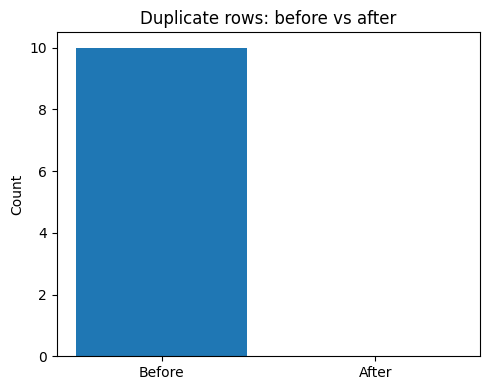

In [80]:
!pip install matplotlib
import matplotlib.pyplot as plt

dups_before = df.duplicated().sum()
dups_after = df_clean.duplicated().sum()

plt.figure(figsize=(5,4))
plt.bar(["Before", "After"], [dups_before, dups_after])
plt.title("Duplicate rows: before vs after")
plt.ylabel("Count")
plt.tight_layout()
plt.show()




<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
